 # Trajectory analysis
 
This notebook is created to analyse the trajectory case series of the `SCENES` project.

In [40]:
import os
import re
import datetime
import math
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, LogLocator, FuncFormatter,  AutoMinorLocator , FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from pdf2image import convert_from_path
from matplotlib import rcParams
from cmcrameri import cm     #Scientific color maps
from itertools import cycle
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import csv 
import gc
import random
from IPython.display import display, Markdown
import inspect

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 12

In [3]:
# Root path- project directory
root_dir = os.path.abspath("..")

In [4]:
# Color palettes

# Choose the color palette from cmcrameri
cmap = cm.batlow
cmap_blues = plt.colormaps["Blues"] 

# Define the custom color palette for photoreceptors
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

In [6]:
# Create and save data tree for measurement folder

output_file = os.path.join("../results/datatree.txt")

lines = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Skip hidden folders and files (like .git, .ipynb_checkpoints, etc.)
    dirnames[:] = [d for d in sorted(dirnames) if not d.startswith('.')]
    filenames = [f for f in sorted(filenames) if not f.startswith('.')]

    rel_path = os.path.relpath(dirpath, root_dir)
    depth = 0 if rel_path == "." else rel_path.count(os.sep) + 1
    indent = "│   " * (depth - 1)

    # Folder name
    folder_name = os.path.basename(dirpath) if rel_path != "." else os.path.basename(os.path.normpath(root_dir))
    lines.append(f"{indent}{folder_name}/")

    # Files inside folder
    for i, file in enumerate(filenames):
        connector = "└── " if i == len(filenames) - 1 else "├── "
        lines.append(f"{indent}    {connector}{file}")

tree_text = "\n".join(lines)

# Save to file
with open(output_file, "w", encoding="utf-8") as f:
    f.write(tree_text)
    


## Import Jeti-metadata file


In [5]:
# Data frame for merged metadata and jeti/klein df
merged_metadata_jeti_df = pd.read_csv(r'..\data\metadata_jeti_scenes.csv', index_col=0, dtype={'time': str})

# Replace all NaN cells with blanks
merged_metadata_jeti_df = merged_metadata_jeti_df.fillna('')


In [6]:
merged_metadata_jeti_df.head()

,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,...,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
0,20230208T0800,101,SCENES,20230208,Niloufar Tabandeh,1.0,Full setup,,1001,1001_20230208T0800,...,0.0,35.1,0.0,142.6,4.0,0.000,0.5,5.1,29.1,451.6
1,20230208T0830,101,SCENES,20230208,Niloufar Tabandeh,2.0,Full setup,,1001,1001_20230208T0830,...,0.0,175.0,0.0,28.6,21.0,0.000,0.6,8.9,30.9,164.2
2,20230208T0900,101,SCENES,20230208,Niloufar Tabandeh,3.0,Full setup,,1001,1001_20230208T0900,...,0.0,367.6,0.0,13.6,38.9,0.001,0.7,10.3,33.5,123.1
3,20230208T0930,101,SCENES,20230208,Niloufar Tabandeh,4.0,Full setup,,1001,1001_20230208T0930,...,0.0,531.5,0.0,9.4,51.7,0.001,0.7,11.0,34.8,107.4
4,20230208T1000,101,SCENES,20230208,Niloufar Tabandeh,5.0,Full setup,,1001,1001_20230208T1000,...,0.0,638.0,0.0,7.8,58.9,0.001,0.8,11.3,35.5,103.1


## Trajectory data frame, measured sequences

In [7]:
trajectory_canada_df = merged_metadata_jeti_df[
    (merged_metadata_jeti_df['protocol'] == 'Trajectory') &
    (merged_metadata_jeti_df['location'] == 'Ottawa-CA')
]
trajectory_canada_df.shape

(63, 235)

In [8]:
trajectory_canada_df.head()


,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,...,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
228,20230614T0800,101,SCENES,20230208,Niloufar Tabandeh,229.0,Full setup,,1012,1012_20230614T0800,...,0.0,0.1,0.0,75790.8,0.0,0.000,0.5,7.7,34.4,202.6
229,20230614T0830,101,SCENES,20230208,Niloufar Tabandeh,230.0,Full setup,,1012,1012_20230614T0830,...,0.0,0.7,0.0,7082.6,0.1,0.001,0.6,5.5,37.0,764.9
230,20230614T0900,101,SCENES,20230208,Niloufar Tabandeh,231.0,Full setup,,1012,1012_20230614T0900,...,0.0,53.1,0.0,94.2,4.1,0.001,0.8,10.1,37.8,160.9
231,20230614T0930,101,SCENES,20230208,Niloufar Tabandeh,232.0,Full setup,,1012,1012_20230614T0930,...,0.0,184.0,0.0,27.2,13.8,0.001,0.9,11.0,37.9,109.4
232,20230614T0945,101,SCENES,20230208,Niloufar Tabandeh,233.0,Full setup,,1012,1012_20230614T0945,...,0.0,52.5,0.0,95.2,6.8,0.001,0.9,15.0,37.5,94.4


In [9]:
copy_trajectory_canada_df = trajectory_canada_df.copy()

# Convert timestamp to datetime
copy_trajectory_canada_df['datetime'] = pd.to_datetime(copy_trajectory_canada_df['timestamp'], format='%Y%m%dT%H%M')
copy_trajectory_canada_df['date'] = copy_trajectory_canada_df['datetime'].dt.date
copy_trajectory_canada_df['time'] = copy_trajectory_canada_df['datetime'].dt.time

metrics = [
    'Illuminance [lx] (CIE1931 2°)',
    'X v,mel,D65 (MEDI) [lx]' 
]

# Pivot table: one row per time, columns = date × metric
pivot_photopic_melanopic_trajectory_canada_df = copy_trajectory_canada_df.pivot_table(
    index='time',      # rows = time only
    columns='date',    # columns = dates
    values=metrics,    # metrics to pivot
    aggfunc='first'     # take the first value for each time/date (we have just one value for each timestamp)
).reset_index()

# Rename metrics
rename_map = {
    'Illuminance [lx] (CIE1931 2°)': 'Photopic illuminance (lux)',
    'X v,mel,D65 (MEDI) [lx]': 'Melanopic-EDI (lux)'
}
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.rename(columns=rename_map, level=0)

# Replace NaNs with empty string
pivot_photopic_melanopic_trajectory_canada_df = pivot_photopic_melanopic_trajectory_canada_df.fillna("")
pivot_photopic_melanopic_trajectory_canada_df.to_csv(r'..\results\pivot_photopic_melanopic_trajectory_canada.csv', index=False)
pivot_photopic_melanopic_trajectory_canada_df

time Photopic illuminance (lux)                        \
date                           2023-06-14 2023-06-16 2023-06-19   
0     08:00:00                       36.1       37.3       43.8   
1     08:30:00                      130.2      110.0      114.1   
2     09:00:00                     4553.4    15976.8     6286.0   
3     09:30:00                    15164.0    14620.2    11627.8   
4     09:45:00                     7540.7                         
5     10:00:00                    12543.8    14606.9    12254.8   
6     10:30:00                      464.6      154.2     3768.2   
7     11:00:00                      493.4      154.9     4047.0   
8     11:30:00                      421.9      155.9     4429.0   
9     12:00:00                      379.3      156.7     4311.8   
10    12:30:00                      359.1      156.2     3715.6   
11    13:00:00                     4904.2    15422.8    34813.6   
12    13:30:00                      639.1      941.1     1353.8   
13    14:00:00                      327.5      161.6     6518.5   
14    14:30:00                      279.3      165.1     7671.7   
15    15:00:00                      325.8      165.4     7671.2   
16    15:30:00                      251.5      165.8     8977.6   
17    16:00:00                     5845.9    12023.0     8389.2   
18    16:30:00                     8367.5    15424.6              
19    17:00:00                     1500.3     2813.6              
20    17:30:00                       63.8       27.0       31.4   
21    18:00:00                       37.2       33.4       61.8   
22    18:30:00                       35.9                         

     Melanopic-EDI (lux)                        
date          2023-06-14 2023-06-16 2023-06-19  
0                   19.0       20.4       23.0  
1                   92.0       70.8       81.1  
2                 4227.6    14421.8     6155.2  
3                14287.4    13535.0    10942.8  
4                 7474.6                        
5                11539.1    13503.6    11466.1  
6                  355.0       93.2     3527.1  
7                  378.2       93.5     3858.5  
8                  320.2       93.9     4130.5  
9                  286.4       94.5     4171.3  
10                 269.7       94.3     3421.9  
11                4439.6    14938.9    33750.6  
12                 551.7      845.3     1185.9  
13                 248.2       97.9     6252.4  
14                 207.8       99.9     7325.8  
15                 245.8      100.5     7678.2  
16                 185.7      100.6     8660.9  
17                5553.3    10945.2     7783.4  
18                7709.9    14772.3             
19                1408.0     2715.7             
20                  47.1       22.2       24.2  
21                  18.4       24.4       46.3  
22                  17.5

In [10]:
# Extract date part (first 8 characters: yyyymmdd)

trajectory_canada_dates = copy_trajectory_canada_df['date'].astype(str).unique().tolist()
trajectory_canada_dates

['2023-06-14', '2023-06-16', '2023-06-19']

In [11]:
# Extract time part (last 4 characters: hhdd)

trajectory_canada_times = copy_trajectory_canada_df['time'].astype(str).unique().tolist()
trajectory_canada_times

['08:00:00',
 '08:30:00',
 '09:00:00',
 '09:30:00',
 '09:45:00',
 '10:00:00',
 '10:30:00',
 '11:00:00',
 '11:30:00',
 '12:00:00',
 '12:30:00',
 '13:00:00',
 '13:30:00',
 '14:00:00',
 '14:30:00',
 '15:00:00',
 '15:30:00',
 '16:00:00',
 '16:30:00',
 '17:00:00',
 '17:30:00',
 '18:00:00',
 '18:30:00']

In [12]:
# Create summary table  
grouped_df = copy_trajectory_canada_df.groupby(['date', 'view']).size().reset_index(name='count')

# Create a new column 'type' based on 'view'
grouped_df['index'] = grouped_df['view'].apply(lambda x: 'outdoor' if x == 'Outdoor' else 'indoor')

# Pivot the DataFrame to have 'Outdoor' and 'Indoor' as separate columns
pivot_summary_df = grouped_df.pivot_table(index='date', columns='index', values='count', aggfunc='sum', fill_value=0).reset_index()
# Add a 'Total' column to sum up counts for each date
pivot_summary_df['sum'] = pivot_summary_df[['indoor', 'outdoor']].sum(axis=1)

summary_row = {
    'date': 'total',
    'indoor': pivot_summary_df['indoor'].sum(),
    'outdoor': pivot_summary_df['outdoor'].sum(),
    'sum': pivot_summary_df['sum'].sum()
}
pivot_summary_df = pd.concat(
    [pivot_summary_df, pd.DataFrame([summary_row])],
    ignore_index=True
)
pivot_summary_df.index = pivot_summary_df.index + 1
pivot_summary_df.to_csv(r'..\results\pivot_summary_trajectory_canada.csv', index=False)
pivot_summary_df


,date,indoor,outdoor,sum
1,2023-06-14,16,7,23
2,2023-06-16,14,7,21
3,2023-06-19,15,4,19
4,total,45,18,63


### Environmental light data

In [31]:
paths = [
    r"..\data\20230614RoofBox1min.csv",
    r"..\data\20230616RoofBox1min.csv",
    r"..\data\20230619RoofBox1min.csv",
]

env_illuminance_14_df , env_illuminance_16_df , env_illuminance_19_df= map(pd.read_csv, paths)

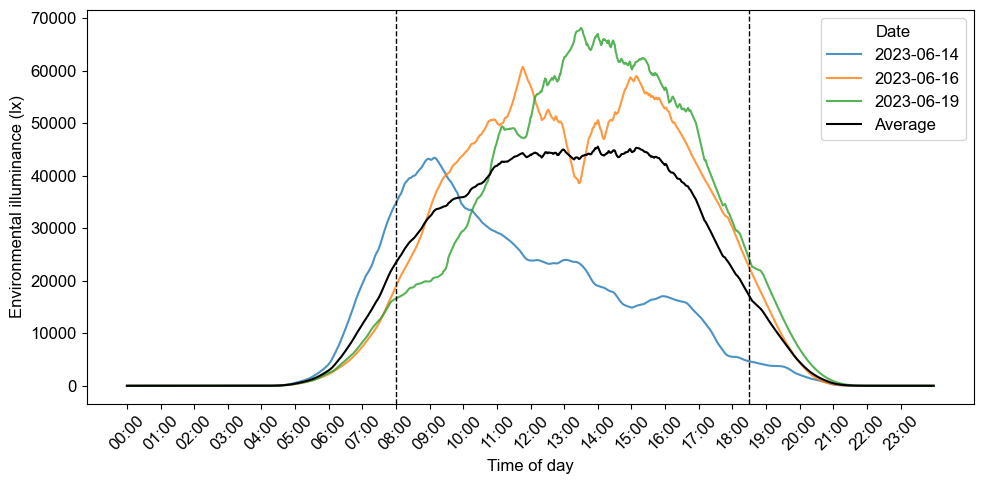

In [54]:
plt.figure(figsize=(10, 5))

smoothed_series = []

for df in (env_illuminance_14_df, env_illuminance_16_df, env_illuminance_19_df):
    df = df.copy()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.sort_values("DateTime")

    x = df["DateTime"].dt.strftime("%H:%M")
    y = df["Out Ill (Lux)"]

    y_smooth = y.rolling(window=100, center=True, min_periods=1).mean()
    smoothed_series.append(y_smooth.values)

    label = df["DateTime"].dt.date.iloc[0].isoformat()
    plt.plot(x, y_smooth, alpha=0.8, label=label)

# --- average line ---
avg_y = np.mean(smoothed_series, axis=0)
plt.plot(x, avg_y, color="black", linewidth=1.5, label="Average")

# x-ticks every 1 hour (1-min data)
tick_pos = list(range(0, len(x), 60))
tick_lab = x.iloc[::60]
plt.xticks(tick_pos, tick_lab, rotation=45)

plt.xlabel("Time of day")
plt.ylabel("Environmental illuminance (lx)")
plt.legend(title="Date")

# --- vertical reference lines ---
time_labels = x.tolist()

idx_0800 = time_labels.index("08:00")
idx_1830 = time_labels.index("18:30")

plt.axvline(idx_0800, color="black", linestyle="--", linewidth=1)
plt.axvline(idx_1830, color="black", linestyle="--", linewidth=1)

plt.tight_layout()

### Photopic illuminance

In [13]:
# Group by time and compute mean, min, max, Q1, Q3, and IQR
photopic_stats = copy_trajectory_canada_df.groupby('time')['Illuminance [lx] (CIE1931 2°)'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
photopic_stats['iqr'] = photopic_stats['q3'] - photopic_stats['q1']

# Round mean to 2 decimals
photopic_stats['mean'] = photopic_stats['mean'].round(2)

# Reset index if needed
photopic_stats = photopic_stats.reset_index()
photopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,39.07,36.1,43.8,36.700,40.550,3.85
1,08:30:00,118.10,110.0,130.2,112.050,122.150,10.10
2,09:00:00,8938.73,4553.4,15976.8,5419.700,11131.400,5711.70
3,09:30:00,13804.00,11627.8,15164.0,13124.000,14892.100,1768.10
4,09:45:00,7540.70,7540.7,7540.7,7540.700,7540.700,0.00
5,10:00:00,13135.17,12254.8,14606.9,12399.300,13575.350,1176.05
6,10:30:00,1462.33,154.2,3768.2,309.400,2116.400,1807.00
7,11:00:00,1565.10,154.9,4047.0,324.150,2270.200,1946.05
8,11:30:00,1668.93,155.9,4429.0,288.900,2425.450,2136.55
9,12:00:00,1615.93,156.7,4311.8,268.000,2345.550,2077.55


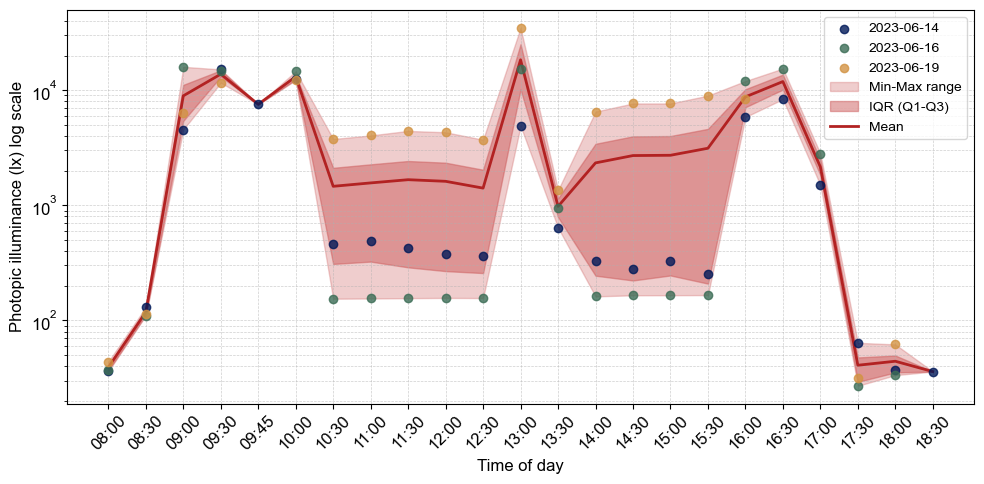

In [56]:
# Plot photopic illuminance for measurement days with central stats
fig, ax = plt.subplots(figsize=(10,5))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['Illuminance [lx] (CIE1931 2°)'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label

# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['q1'],
    photopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['min'],
    photopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in photopic_stats['time']],
    photopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')
# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Photopic illuminance (lx) log scale')
#ax.set_title('Photopic illuminance per measurement day')
# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.6, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../results/plots/photopic_illuminance_trajectory_days.pdf', bbox_inches='tight')
fig.savefig('../results/plots/photopic_illuminance_trajectory_days.png', bbox_inches='tight')

### Melanopic_EDI

In [14]:
# Group by time and compute mean, min, max, Q1, Q3, and IQR
melanopic_stats = copy_trajectory_canada_df.groupby('time')['X v,mel,D65 (MEDI) [lx]'].agg(
    mean='mean',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
# Add IQR column
melanopic_stats['iqr'] = melanopic_stats['q3'] - melanopic_stats['q1']

# Round mean to 2 decimals
melanopic_stats['mean'] = melanopic_stats['mean'].round(2)

# Reset index if needed
melanopic_stats = melanopic_stats.reset_index()
melanopic_stats

,time,mean,min,max,q1,q3,iqr
0,08:00:00,20.80,19.0,23.0,19.700,21.700,2.00
1,08:30:00,81.30,70.8,92.0,75.950,86.550,10.60
2,09:00:00,8268.20,4227.6,14421.8,5191.400,10288.500,5097.10
3,09:30:00,12921.73,10942.8,14287.4,12238.900,13911.200,1672.30
4,09:45:00,7474.60,7474.6,7474.6,7474.600,7474.600,0.00
5,10:00:00,12169.60,11466.1,13503.6,11502.600,12521.350,1018.75
6,10:30:00,1325.10,93.2,3527.1,224.100,1941.050,1716.95
7,11:00:00,1443.40,93.5,3858.5,235.850,2118.350,1882.50
8,11:30:00,1514.87,93.9,4130.5,207.050,2225.350,2018.30
9,12:00:00,1517.40,94.5,4171.3,190.450,2228.850,2038.40


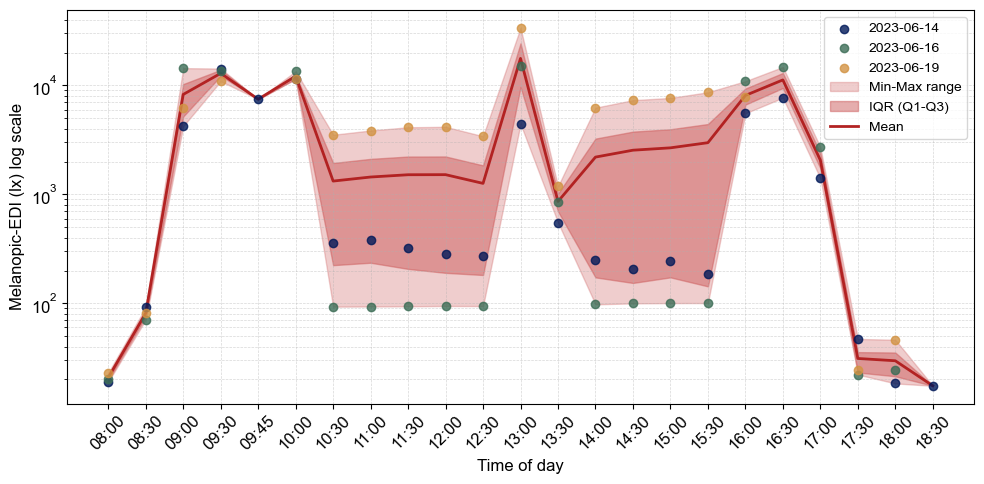

In [15]:
# Plot photopic illuminance for measurement days with central stats
fig, ax = plt.subplots(figsize=(10,5))

scatter_handles = []  # to collect scatter handles for legend
colors = [cm.batlow(i/len(copy_trajectory_canada_df['date'].unique())) for i in range(len(copy_trajectory_canada_df['date'].unique()))]

# Plot each day's measurements as scatter
for i, date in enumerate(copy_trajectory_canada_df['date'].unique()):
    day_data = copy_trajectory_canada_df[copy_trajectory_canada_df['date'] == date]
    sc = ax.scatter(
        [t.strftime('%H:%M') if not isinstance(t, str) else t[:5] for t in day_data['time']],
        day_data['X v,mel,D65 (MEDI) [lx]'],
        color=colors[i],
        alpha=0.8,
        zorder=4
    )
    scatter_handles.append((sc, str(date)))  # store handle + label


# Fill area between Q1 and Q3 (IQR)
iqr_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['q1'],
    melanopic_stats['q3'],
    color='indianred',
    alpha=0.5,
    zorder=1,
    label='IQR (Q1-Q3)'
)

# Fill area between min and max
minmax_fill = ax.fill_between(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['min'],
    melanopic_stats['max'],
    color='indianred',
    alpha=0.3,
    zorder=0,
    label='Min-Max'
)

# Overlay mean lines
mean_line, = ax.plot(
    [t.strftime('%H:%M') for t in melanopic_stats['time']],
    melanopic_stats['mean'],
    color='firebrick',
    linewidth=2,
    label='Mean',
    zorder=3
)

# Create legend: one handle per day + fill + mean
handles = [h for h, l in scatter_handles] + [minmax_fill, iqr_fill, mean_line]
labels = [l for h, l in scatter_handles] + ['Min-Max range', 'IQR (Q1-Q3)', 'Mean']

ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)

# Log scale
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Time of day')
ax.set_ylabel('Melanopic-EDI (lx) log scale')
#ax.set_title('Melanopic-EDI per day')

# Grid with minor lines
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

# Format x-axis ticks
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../results/plots/melanopic_trajectory_days.pdf', bbox_inches='tight')
fig.savefig('../results/plots/melanopic_trajectory_days.png', bbox_inches='tight')

### Photopic illuminance vr Melanopic EDI

In [16]:
# Pearson correlation coefficient

correlation_coefficient = trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].corr(trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'])

print( f" Correlation Coefficient between mEDI and Illuminance from Jeti: {correlation_coefficient}")

 Correlation Coefficient between mEDI and Illuminance from Jeti: 0.9995190290327606


In [27]:
# Create a new column 'in/out' based on 'view'
trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_6168\2618375490.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')
C:\Users\ntabandeh\AppData\Local\Temp\ipykernel_6168\2618375490.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


In [28]:
# Calculate correlation coefficient for Indoor data

# Calculate correlation coefficient for Indoor data
indoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Indoor']
correlation_indoor = indoor_data['Illuminance [lx] (CIE1931 2°)'].corr(indoor_data['X v,mel,D65 (MEDI) [lx]'])

# Calculate correlation coefficient for Outdoor data
outdoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Outdoor']
correlation_outdoor = outdoor_data['Illuminance [lx] (CIE1931 2°)'].corr(outdoor_data['X v,mel,D65 (MEDI) [lx]'])

# Print the results
print(f"Correlation Coefficient for Indoor data: {correlation_indoor}")
print(f"Correlation Coefficient for Outdoor data: {correlation_outdoor}")

Correlation Coefficient for Indoor data: 0.9996614058418479
Correlation Coefficient for Outdoor data: 0.9991835426132162


In [29]:
# Plot mEDI for each day in one plot, log10 scale (Jeti)

# Get a colormap and normalize it based on the number of groups
  
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize = (10,7)) 

x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    jeti_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'], jeti_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], jeti_values, marker='o', color=color)
    
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(jeti_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
plt.yscale('log')    
plt.xlabel('Time')
plt.ylabel('log(mEDI [lx])')
plt.title('mEDI from Jeti in log scale')
plt.legend(loc='upper right');

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_mEDI_Trajectory.pdf',dpi = 600, bbox_inches='tight');

KeyError: 'date'

In [ ]:
# Plot illuminace and mEDI for each day in log scale (Jeti)

# Get a colormap and normalize it based on the number of groups
cmap_ill = mpl.colormaps['winter']  
cmap_medi = mpl.colormaps['autumn'] 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))


for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    plt.figure(figsize = (8,5))  # Create a new figure for each group
    
    color_illuminance = cmap_ill(norm(i))

    color_medi = cmap_medi(norm(i))
        
    jeti_illuminance = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    
    plt.plot(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], label='Illuminance', color=color_illuminance)
    plt.scatter(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], marker='o', color=color_illuminance)
    
    jeti_medi = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    plt.plot(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], label='mEDI', alpha = 0.8, color=color_medi)
    plt.scatter(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], marker='o', alpha = 0.8, color=color_medi)
    
    plt.yscale('log')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.ylabel('log[lx]')
    plt.title(f'Photopic illuminance and mEDI from Jeti in log scale_date{group}')
    plt.legend(loc='upper right');

    # Adjust layout for better spacing
    plt.tight_layout()
    
    #plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_{group}.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illuminace and mEDI ratio in one plot for all days in one plot (Jeti)

# Get a colormap and normalize it based on the number of groups 
 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))
plt.figure(figsize = (10,7))
x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    illuminance_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    medi_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    ratio_values = illuminance_values / medi_values
    
    color = cmap(norm(i))
    
    plt.plot(group_df['time'], ratio_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], ratio_values, marker='o', color=color)
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(ratio_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
      
plt.xlabel('Time')
plt.ylabel('Ratio (illuminance/mEDI)')
plt.title('Photopic illuminance and mEDI ratio from Jeti')
plt.legend(loc='upper center');

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_ratio.pdf', dpi = 600, bbox_inches="tight");

In [ ]:
# Plot illumnance vr mEDI for all trajectory days in one plot (Jeti)

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    # Drop rows with NaN values in the specified columns
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)
    

# Perform linear regression for y = mx + b
model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
m = model.coef_[0]
b = model.intercept_

# Generate x values for the regression line
regression_line_x = np.linspace(0, x_values, 100).reshape(-1, 1)
    
# Calculate corresponding y values for the regression line
regression_line_y = m * regression_line_x + b
    
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'y = {m:.2f}x + {b:.2f}')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(x_values, y_values)

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'y = {m:.2f}x')
    
# Set limits based on the current plot's maximum value
plt.xlim(0)
plt.ylim(0)
plt.xlabel('mEDI [lx]')
plt.ylabel('Illuminance [lx]')
plt.legend(loc = 'upper left')
plt.title(f'Illuminance vr mEDI for trajectory days');


In [ ]:

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)

# Perform linear regression for log-transformed values
model = LinearRegression()
model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
m = model.coef_[0]
b = model.intercept_

    # Generate log-transformed x values for the regression line
regression_line_x = np.linspace(x_values.min(), x_values.max(), 100)
regression_line_x_log = np.log10(regression_line_x)    
# Calculate corresponding log-transformed y values for the regression line
regression_line_y_log = m * regression_line_x_log + b
regression_line_y = 10 ** regression_line_y_log
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'log fit, y = {b:.2f}+ {m:.2f}x')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(np.log10(x_values), np.log10(y_values))

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'log fit, y = {m2:.2f}x')



plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale

plt.xlabel('log(mEDI [lx])')
plt.ylabel('log(Illuminance [lx])')
plt.legend(loc='upper left')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)
plt.title(f'Illuminance vr mEDI in log 10 for trajectory days');


#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI.pdf', dpi = 600, bbox_inches='tight');

In [ ]:
# Create subplots for two groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for (group, group_df), ax in zip(trajectory_canada_df.groupby('in/out'), [ax1, ax2]):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = ax.scatter(x_values, y_values, label=group)

    # Perform linear regression for log-transformed values
    model = LinearRegression()
    model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
    m = model.coef_[0]
    b = model.intercept_

    # Generate log-transformed x values for the regression line
    regression_line_x = np.linspace(x_values.min(), x_values.max(), 100).reshape(-1, 1)
    regression_line_x_log = np.log10(regression_line_x)    
    # Calculate corresponding log-transformed y values for the regression line
    regression_line_y_log = m * regression_line_x_log + b
    regression_line_y = 10 ** regression_line_y_log
    # Plot the regression line
    ax.plot(regression_line_x, regression_line_y, color='black', label=f'logaritmic fit, y = {b:.2f}+ {m:.2f}x')

    # Perform linear regression for y = m2x
    model_new = LinearRegression()
    model_new.fit(np.log10(x_values), np.log10(y_values))

    # Get regression line parameters for the new line
    m2 = model_new.coef_[0]

    # Calculate corresponding y values for the new regression line (y = mx)
    regression_line_y_new = m2 * regression_line_x

    # Plot the new regression line
    ax.plot(regression_line_x, regression_line_y_new, color='red', label=f'logaritmic fit, y = {m2:.2f}x')

    ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_yscale('log')  # Set y-axis to log scale

    ax.set_xlabel('log(mEDI [lx])')
    ax.set_ylabel('log(Illuminance [lx])')
    ax.legend(loc='upper left')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.5)
    ax.set_title(f'Illuminance vs mEDI for {group} trajectory days')
    # Set x and y limits explicitly
    ax.set_xlim(10, 1e5)
    ax.set_ylim(10, 1e5)
plt.tight_layout()

#plt.savefig('results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI_inout.pdf', dpi = 600, bbox_inches='tight');

## Next step: Now I want table for fit and error. Not correct, will check it later

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
cleaned_df = trajectory_canada_df[[x_column, y_column]].dropna()

In [ ]:

# Perform linear regression for y = mx + b
tidy_trajectory_canada_df = trajectory_canada_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])

x_values = tidy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
y_values = tidy_trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].values

model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
slope = model.coef_[0]
intercept = model.intercept_

# Calculate variance (mean squared error)
predictions = model.predict(x_values)
variance = mean_squared_error(y_values, predictions)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print (f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
print(f"Variance (Mean Squared Error): {variance:.2f}")

In [ ]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
tidy_trajectory_canada_df = tidy_trajectory_canada_df.dropna(subset=[x_column, y_column, 'in/out'])

# Group by 'in/out' and perform linear regression for each group
for group, group_df in tidy_trajectory_canada_df.groupby('in/out'):
    # Extract the x and y values for the current group
    x_values = group_df[x_column].values.reshape(-1, 1)
    y_values = group_df[y_column].values

    # Perform linear regression
    model = LinearRegression()
    model.fit(x_values, y_values)

    # Get regression line parameters
    slope = model.coef_[0]
    intercept = model.intercept_

    # Calculate variance (mean squared error)
    predictions = model.predict(x_values)
    variance = mean_squared_error(y_values, predictions)

    print(f"Group: {group}")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f'y = {slope:.2f}x + {intercept:.2f}')
    print(f"Variance (Mean Squared Error): {variance:.2f}")
    print()

In [ ]:
tidy_trajectory_canada_df

In [ ]:
# Calculate the number of combinations
n = 63
r = 21
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

In [ ]:
# Calculate the number of combinations
n = 63
r = 8
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

## Trajectory models, synthetic sequences


In [110]:
# Define the trajectory bins as placeholders for the synthetic days (22 time slots)
placeholders = ['MH01', 'MH02', 'MC03', 'MC04', 'MC05', 'MO06', 'MO07', 'MO08', 'MO09', 'MO10', 'NN11', 'NN12', 'AO13', 'AO14', 'AO15', 'AO16', 'AC17', 'AC18', 'AC19', 'AH20', 'AH21', 'AH22']
len(placeholders)

22

In [111]:

    times = [f"{h:02d}:{m:02d}" for h, m in
         [(8,0),(8,30),(9,0),(9,30),(10,0),(10,30),(11,0),(11,30),
          (12,0),(12,30),(13,0),(13,30),(14,0),(14,30),(15,0),(15,30),
          (16,0),(16,30),(17,0),(17,30),(18,0),(18,30)]]


In [117]:
def plot_model_timeline_iqr_multi(
    sequence_dict,
    placeholders,
    times,
    metric_name="Melanopic-EDI",
    save_dir="../results/plots",
    dpi=300,
    ylog=True,
    ylims=(1e-1, 1e5),
):
    """
    Generate and save one timeline-IQR plot per model.
    Model names are derived from dict keys by removing '_model'.
    """

    n_models = len(sequence_dict)

    for i, (key, sequences) in enumerate(sequence_dict.items()):
        # Derive model name
        model_name = key.replace("_model", "")

        # Assign colour from cm.batlow
        color_pos = i / max(n_models - 1, 1)
        base_color = cm.batlow(color_pos)

        # Call single-plot function
        plot_model_timeline_iqr(
            sequences,
            placeholders=placeholders,
            times=times,
            metric_name=metric_name,
            sequences_name=model_name,
            save_dir=save_dir,
            dpi=dpi,
            base_color=base_color,
            show_median=False
        )

In [146]:
def plot_model_timeline_iqr(
    sequences,
    placeholders=None,
    times=None,
    base_color=None,
    metric_name="Melanopic-EDI",
    sequences_name=None,
    save_dir="../results/plots",
    dpi=300,
    show_median=False,
    add_whiskers=False,
    whiskers=(5, 95),
):
    """
    Summarise per-placeholder distribution across Monte Carlo sequences and plot:
      - mean as a dotted line
      - interquartile range (25–75%) as a shaded band
      - optional median line and/or 5–95% whisker band

    Parameters
    ----------
    sequences : np.ndarray, shape (n_slots, n_sequences)
        Each column is one synthetic day; each row is a placeholder/time slot.
    placeholders : list[str] or None
        X-axis labels. If None, auto-generate PH01..PHxx.
    metric_name : str
        Used for axis label/title.
    sequences_name : str or None
        If provided, used in output filenames.
    """

    sequences = np.asarray(sequences)
    n_slots, _ = sequences.shape

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    x = np.arange(n_slots)

    mean = sequences.mean(axis=1)
    ymin = sequences.min(axis=1)
    ymax = sequences.max(axis=1)
    q25 = np.percentile(sequences, 25, axis=1)
    q75 = np.percentile(sequences, 75, axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    if base_color is None:
        base_color = cm.batlow(0.6)  # fallback

    # Range
    ax.fill_between(x, ymin, ymax, color=base_color, alpha=0.2, label="Range (min–max)", zorder=3)

    # IQR band
    ax.fill_between(x, q25, q75, color=base_color, alpha=0.5, label="IQR (25–75%)", zorder=5)

    # Mean dotted line
    ax.plot(x, mean, linewidth=2, marker="o", color=base_color, label="Mean", markeredgecolor="black", markeredgewidth=0.6, zorder=7)

    # Optional median
    if show_median:
        med = np.median(sequences, axis=1)
        ax.plot(x, med, linestyle="-", marker=None, label="Median")

    # Optional 5–95% band
    if add_whiskers:
        lo = np.percentile(sequences, whiskers[0], axis=1)
        hi = np.percentile(sequences, whiskers[1], axis=1)
        ax.fill_between(x, lo, hi, alpha=0.12, label=f"{whiskers[0]}–{whiskers[1]}%")

    ax.set_xticks(x)
    ax.set_xticklabels(placeholders, rotation=45, ha="center", fontsize=9)
    ax.set_xlabel("Placeholder", fontsize=11)
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())  # align with bottom axis
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(times, rotation=45, ha="center", fontsize=9)
    ax_top.set_xlabel("Time of day", fontsize=11)

    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1e5)
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.tick_params(axis="y", labelsize=10)
    # ax.set_title(f"Per-placeholder distribution across synthetic sequences: {metric_name}")
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    leg = ax.legend(loc="lower right", fontsize=9, title=sequences_name)
    leg.get_title().set_fontsize(10)
    plt.tight_layout()

    if sequences_name:
        safe = str(sequences_name).replace(" ", "_")
        base = f"{save_dir}/Placeholder_distribution_IQR_{safe}"
        fig.savefig(base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(base + ".pdf", bbox_inches="tight")

    stats = {"mean": mean, "q25": q25, "q75": q75}
    if show_median:
        stats["median"] = np.median(sequences, axis=1)
    if add_whiskers:
        stats["p_lo"] = np.percentile(sequences, whiskers[0], axis=1)
        stats["p_hi"] = np.percentile(sequences, whiskers[1], axis=1)

    return stats

In [167]:
def plot_monte_carlo_stability_heatmap(
    sequences,
    repeats=(100, 1000, 10000, 100000),
    n_runs=50,
    rel_threshold=0.01,
    metric_name="Melanopic-EDI",
    sequences_name=None,
    placeholders=None,
    seed=123,
    reference="full",        
    save_dir="../results/plots",
    dpi=300,
    vmax=5.0,
):
    """
    Heatmap of Monte Carlo convergence (median relative error, %) per placeholder.
    - X axis: placeholders
    - Y axis: repeats (r)
    - Cell value: median relative error (%) across n_runs
    - Fixed vmax (%) for comparability across models
    """
    sequences = np.asarray(sequences)
    n_slots, n_seq = sequences.shape
    repeats = list(repeats)

    if placeholders is None:
        placeholders = [f"PH{i+1:02d}" for i in range(n_slots)]
    if len(placeholders) != n_slots:
        raise ValueError("Length of `placeholders` must match sequences.shape[0].")

    rng = np.random.default_rng(seed)
    # Reference mean: full set
    ref_mean = sequences.mean(axis=1)

    # all_err: run x repeat x slot
    all_err = np.zeros((n_runs, len(repeats), n_slots), dtype=float)

    for j, r in enumerate(repeats):
        r_eff = min(int(r), n_seq)
        for b in range(n_runs):
            # Subsample already-generated sequences (columns)
            idx = rng.choice(n_seq, size=r_eff, replace=False)
            mean_r = sequences[:, idx].mean(axis=1)
            rel_err = np.abs(mean_r - ref_mean) / (np.abs(ref_mean) + 1e-12)
            all_err[b, j, :] = rel_err

    # Median across runs -> % ; shape: repeats x slots
    median_err = np.median(all_err, axis=0) * 100.0

    # ---- Plot  ----
    fig, ax = plt.subplots(figsize=(7, 3))

    im = ax.imshow(
        median_err,
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=float(vmax),
        cmap=cm.batlow,
        alpha=0.9
    )

    # Axes: X = placeholders, Y = repeats
    ax.set_yticks(np.arange(len(repeats)))
    ax.set_yticklabels([f"{r:,}" for r in repeats], rotation=45, fontsize=8)
    ax.set_ylabel("Number of synthetic sequences ", fontsize=10)

    ax.set_xticks(np.arange(n_slots))
    ax.set_xticklabels(placeholders, rotation=45, ha="center", fontsize=8)
    ax.set_xlabel("Placeholder", fontsize=11)

    # Add thin borders around each cell
    ax.set_xticks(np.arange(-0.5, n_slots, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(repeats), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ax.set_title(f"Monte Carlo convergence (median relative error, %) — {metric_name}", fontsize=11)

    # Mark cells meeting criterion (< threshold)
    thr_pct = rel_threshold * 100.0
    ok = median_err < thr_pct
    ys, xs = np.where(ok)
    ax.scatter(xs, ys, s=20, marker="o", facecolors="none", edgecolors="black", linewidths=0.8)

    # Text box: first line = sequence name, second line = criterion
    if sequences_name is None:
        seq_title = "Model"
    else:
        seq_title = str(sequences_name)

    ax.text(
        0.01, 0.99,
        f"Open circles: median relative error < {thr_pct:.1f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9)
    )

    # Compact colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Median relative error (%)", rotation=90, fontsize=9)

    plt.tight_layout()

    # Save
    if sequences_name:
        safe_name = str(sequences_name).replace(" ", "_")
        file_base = f"{save_dir}/MonteCarlo_stability_heatmap_{safe_name}"
        fig.savefig(file_base + ".png", bbox_inches="tight", dpi=dpi)
        fig.savefig(file_base + ".pdf", bbox_inches="tight")

    return median_err, all_err

### Naive model

In [ ]:
# 100000 sequence, random sampling with permutation of 63 melanopic-EDI values in 22 placeholders. 

np.random.seed(20)
n_sequences = 100000  # number of synthetic sequences
n_slots = len(placeholders)

# Generate all sequences at once
naive_sequence = np.array([np.random.choice(melanopic_values, size=n_slots) 
                          for _ in range(n_sequences)]).T 

# Create DataFrame in one shot
naive_synthetic_df = pd.DataFrame(naive_sequence, index=placeholders,
                            columns=[f'seq_{i+1:04d}' for i in range(n_sequences)])

# synthetic_df now has placeholders as index and sequences as columns
print(naive_synthetic_df.shape)
naive_synthetic_df.iloc[:, :10].head()


(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,97.9,100.6,93.9,93.5,355.0,11466.1,100.6,11539.1,14772.3,4227.6
MH02,13535.0,100.6,6155.2,81.1,13535.0,1408.0,22.2,4227.6,4439.6,1408.0
MC03,245.8,46.3,94.3,355.0,245.8,4171.3,10945.2,7325.8,11539.1,17.5
MC04,94.5,185.7,269.7,207.8,7709.9,11466.1,2715.7,20.4,19.0,81.1
MC05,93.2,2715.7,24.4,70.8,207.8,24.2,20.4,94.5,7678.2,18.4


In [24]:
naive_synthetic_df.to_csv(r'..\results\naive_melanopic_sequence.csv')

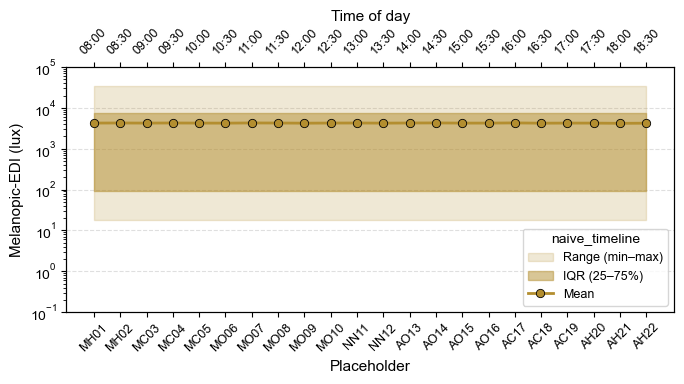

In [ ]:
stats = plot_model_timeline_iqr(
    naive_sequences,
    placeholders=placeholders,
    times=times,
    metric_name="Melanopic-EDI (lx)",
    sequences_name="naive_timeline",
    show_median=False
)

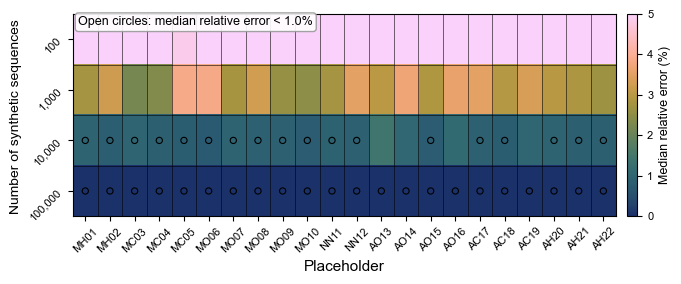

In [168]:
median_err, all_err = plot_monte_carlo_stability_heatmap(
    naive_sequences,
    rel_threshold=0.01,
    sequences_name="naive_model_monte_carlo_convergence",
    placeholders=placeholders,
    save_dir="../results/plots",
    dpi=300
)

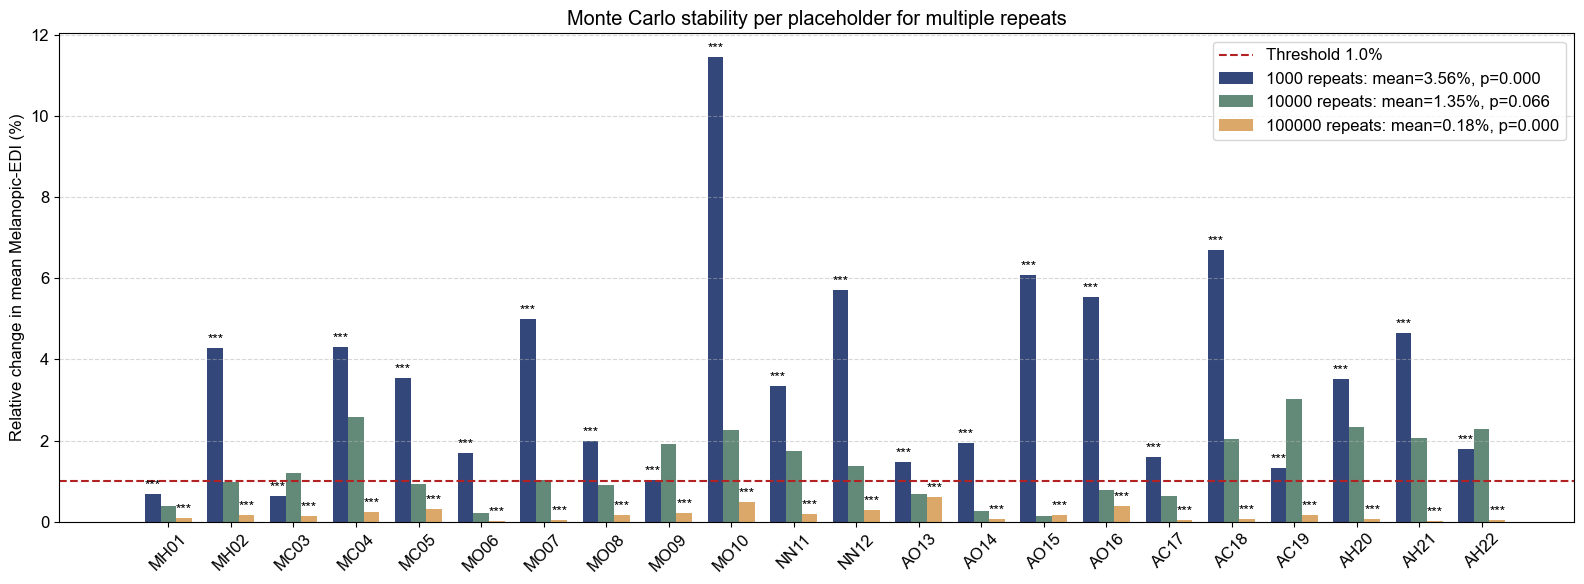

In [65]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    naive_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive'
)


### Naive indoor model

In [83]:
# 100000 sequence, random sampling with permutation of 20 melanopic-EDI values in 22 placeholders.
np.random.seed(20)
# Number of synthetic sequences
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
indoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Indoor', na=False)]

# 2. Extract melanopic values from indoor data only
indoor_melanopic = indoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_indoor_sequences = np.array([
    np.random.choice(indoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
indoor_synthetic_df = pd.DataFrame(
    naive_indoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(indoor_synthetic_df.shape)
indoor_synthetic_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,4130.5,7678.2,355.0,286.4,23.0,18.4,320.2,97.9,24.2,93.5
MH02,100.5,3421.9,47.1,7678.2,4171.3,81.1,19.0,245.8,94.3,7325.8
MC03,17.5,269.7,70.8,94.3,551.7,17.5,94.3,92.0,17.5,245.8
MC04,81.1,3421.9,24.2,18.4,93.5,100.6,3421.9,7678.2,269.7,286.4
MC05,22.2,3858.5,20.4,378.2,81.1,46.3,378.2,93.2,245.8,3527.1


In [ ]:
indoor_synthetic_df.to_csv(r'..\results\naive_indoor_melanopic_sequence.csv')

In [ ]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    naive_indoor_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive_indoor'
)

### Naive outdoor model

In [84]:
# 100000 sequence, random sampling with permutation of 43 melanopic-EDI values in 22 placeholders.
n_sequences = 100000
n_slots = len(placeholders)

# 1. Filter indoor values
outdoor_df = copy_trajectory_canada_df[copy_trajectory_canada_df['view'].str.contains('Outdoor', na=False)]

# 2. Extract melanopic values from indoor data only
outdoor_melanopic = outdoor_df['X v,mel,D65 (MEDI) [lx]'].dropna().values

# 3. Generate sequences: randomly draw indoor values into all placeholders
naive_outdoor_sequences = np.array([
    np.random.choice(outdoor_melanopic, size=n_slots)
    for _ in range(n_sequences)
]).T   # shape: (22, n_sequences)

# 4. Create synthetic DataFrame
outdoor_synthetic_df = pd.DataFrame(
    naive_outdoor_sequences,
    index=placeholders,
    columns=[f'seq_{i+1:04d}' for i in range(n_sequences)]
)
print(outdoor_synthetic_df.shape)
outdoor_synthetic_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,14421.8,10945.2,1408.0,2715.7,14772.3,4227.6,10942.8,4227.6,13535.0,13535.0
MH02,4227.6,10942.8,2715.7,14772.3,14772.3,11539.1,13503.6,4439.6,33750.6,1408.0
MC03,2715.7,2715.7,10942.8,14287.4,14421.8,10942.8,14287.4,13535.0,7709.9,4439.6
MC04,10942.8,13503.6,14287.4,1408.0,14287.4,14287.4,10945.2,14938.9,14287.4,14938.9
MC05,10945.2,4439.6,10942.8,33750.6,13535.0,4227.6,13503.6,33750.6,7709.9,14938.9


In [ ]:
outdoor_synthetic_df.to_csv(r'..\results\naive_outdoor_melanopic_sequence.csv')

In [ ]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    naive_outdoor_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'naive_outdoor'
)

### Time restricted model

In [74]:
df = copy_trajectory_canada_df.copy()
df['datetime'] = pd.to_datetime(df['datetime'])  

# create 22 fixed half-hour bin starts from 07:59 for mid measured day
bin_starts = pd.date_range("2023-06-16 07:59", periods=22, freq="30min").time

# collect values per bin (no new df columns)
mel_bins = []
for start in bin_starts:
    end = (pd.Timestamp("2000-01-01 " + start.strftime("%H:%M")) + pd.Timedelta(minutes=30)).time()
    mask = (df['datetime'].dt.time >= start) & (df['datetime'].dt.time < end)
    vals = df.loc[mask, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    mel_bins.append(vals)

In [75]:
n_sequences = 100000
n_slots = len(mel_bins)   # should be 22

# Generate sequences: one random value from bin i → placeholder i
time_restricted_sequences = np.zeros((n_slots, n_sequences))

for i, bin_values in enumerate(mel_bins):
    bin_values = np.array(bin_values)
    if len(bin_values) == 0:
        raise ValueError(f"Bin {i} is empty. Cannot sample.")
    time_restricted_sequences[i] = np.random.choice(bin_values, size=n_sequences, replace=True)

# Create DataFrame
time_restricted_df = pd.DataFrame(
    time_restricted_sequences,
    index=placeholders, 
    columns=[f"seq_{i+1:04d}" for i in range(n_sequences)]
)
print(time_restricted_df.shape)
time_restricted_df.iloc[:, :10].head()

(22, 100000)


,seq_0001,seq_0002,seq_0003,seq_0004,seq_0005,seq_0006,seq_0007,seq_0008,seq_0009,seq_0010
MH01,19.0,19.0,20.4,23.0,19.0,19.0,20.4,23.0,19.0,23.0
MH02,70.8,81.1,92.0,92.0,92.0,70.8,70.8,70.8,92.0,81.1
MC03,6155.2,6155.2,6155.2,4227.6,4227.6,4227.6,4227.6,6155.2,6155.2,14421.8
MC04,10942.8,13535.0,10942.8,13535.0,13535.0,10942.8,7474.6,10942.8,10942.8,7474.6
MC05,11466.1,11539.1,11539.1,11539.1,13503.6,13503.6,11539.1,13503.6,13503.6,11466.1


In [ ]:
time_restricted_df.to_csv(r'..\results\time_restricted_melanopic_sequence.csv')

In [ ]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    time_restricted_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'time_restricted'
)

### Location restricted model

In [76]:

# Extract hour + minute as float for easier comparison
df['hour_min'] = df['datetime'].dt.hour * 100 + df['datetime'].dt.minute

# Create empty column for placeholder group
df['location_group'] = ''

# Morning (before 12.99 ~ 12:59)
morning_mask = df['hour_min'] <= 1259
afternoon_mask = df['hour_min'] >= 1359
noon_mask = (df['hour_min'] > 1259) & (df['hour_min'] < 1359)

# Morning placeholders
df.loc[morning_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'MH'  # Morning Home
df.loc[morning_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'MO'  # Morning Office
df.loc[morning_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'MC'  # Morning Commute

# Afternoon placeholders
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & ~df['scene'].str.contains('office', case=False),
       'location_group'] = 'AH'  # Afternoon Home
df.loc[afternoon_mask & df['scene'].str.contains('Indoor') & df['scene'].str.contains('office', case=False),
       'location_group'] = 'AO'  # Afternoon Office
df.loc[afternoon_mask & df['scene'].str.contains('Outdoor'),
       'location_group'] = 'AC'  # Afternoon Commute

# Noon placeholders
df.loc[noon_mask, 'location_group'] = 'NN'  # Noon

In [77]:
# Extract melanopic values per activity category
group_to_values = {}

for g in ['MH','MO','MC','AH','AO','AC','NN']:
    vals = df.loc[df['location_group'] == g, 'X v,mel,D65 (MEDI) [lx]'].dropna().values
    group_to_values[g] = vals.astype(float)
# Merge categories based on your mapping
location_map = {
    'H': ['MH', 'AH'],    # Home
    'O': ['MO', 'AO'],    # Office
    'C': ['MC', 'AC'],    # Commute
    'N': ['NN']           # Noon
}
# Build final pools
location_pool = {}
for key, groups in location_map.items():
    merged = np.concatenate([group_to_values[g] for g in groups if len(group_to_values[g]) > 0])
    location_pool[key] = merged

In [79]:
n_sequences = 100000  # number of synthetic sequences
outfile = r"..\results\location_restricted_melanopic_sequence.csv"
# Map each placeholder to its activity type (second character)
placeholder_location = []
for ph in placeholders:
    if ph[:2] == 'NN':  # noon placeholders
        placeholder_location.append('N')
    else:
        placeholder_location.append(ph[1])  # H, O, C

# Initialize matrix
location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

# Fill each placeholder row from the merged activity pool
for i, loc in enumerate(placeholder_location):
    pool = location_pool[loc]  # H, O, C, or N
    location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame
location_restricted_df = pd.DataFrame(location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save CSV
location_restricted_df.to_csv(outfile)
print("Done.")

Done.


In [ ]:
# Monte carlo function and plot but need to find the correct sequence 

### Time/location restricted model

In [86]:
# All time-activity groups in your labeling scheme
codes = ['MH','MO','MC','AH','AO','AC','NN']

time_location_pool = {}
for code in codes:
    vals = df.loc[df['location_group'] == code,
                  'X v,mel,D65 (MEDI) [lx]'].dropna().values
    time_location_pool[code] = vals.astype(float)


In [87]:
n_sequences = 100000
chunk_size = 1000
outfile = r"..\results\time_location_restricted_melanopic_sequence.csv"

# Each placeholder draws from its exact pool (AO → AO, MH → MH, etc.)
time_location_restricted_sequences = np.zeros((len(placeholders), n_sequences))

for i, ph in enumerate(placeholders):
    pool = time_location_pool[ph[:2]]  # first two letters = time + activity
    time_location_restricted_sequences[i, :] = np.random.choice(pool, size=n_sequences)

# Convert to DataFrame: rows = placeholders, columns = sequences
time_location_restricted_df = pd.DataFrame(time_location_restricted_sequences, index=placeholders,
                      columns=[f"seq_{i+1:05d}" for i in range(n_sequences)])

# Save to CSV
time_location_restricted_df .to_csv(outfile)
print("Done.")

Done.


In [ ]:
rel_mean, rel_std, mean_vals, std_vals = plot_monte_carlo_stability_bar_multi(
    time_location_restricted_sequences, placeholders=placeholders, rel_threshold=0.01, sequences_name= 'time_restricted'
)

In [90]:
sequence_dict = {
    "naive_model": naive_sequences,
    "naive_indoor_model": naive_indoor_sequences,
    "naive_outdoor_model": naive_outdoor_sequences,
    "time_restricted_model": time_restricted_sequences,
    "location_restricted_model": location_restricted_sequences,
    "time_location_restricted_model": time_location_restricted_sequences,
}

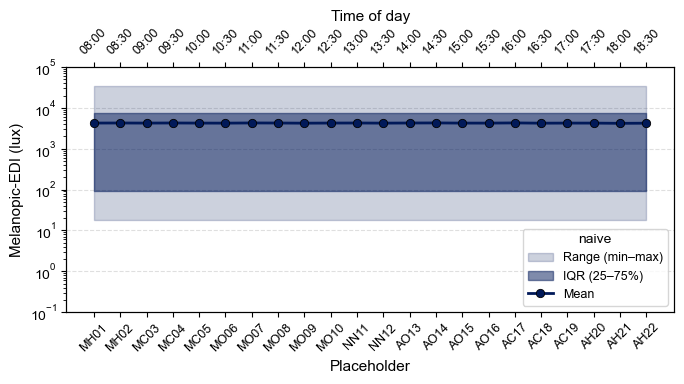

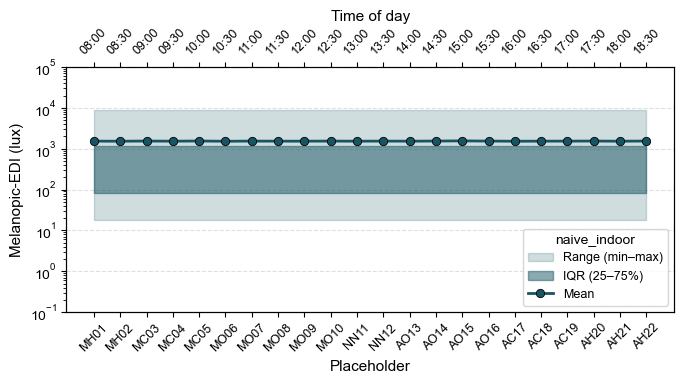

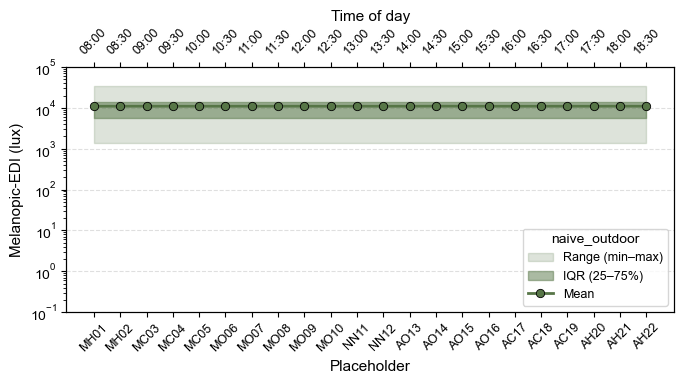

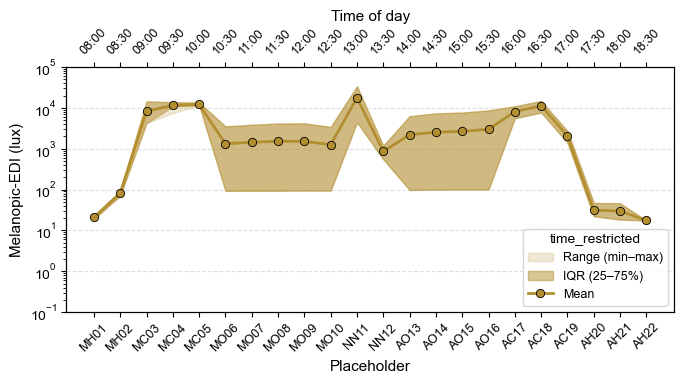

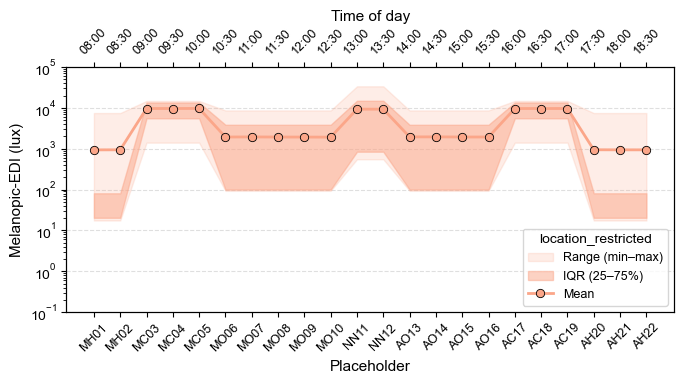

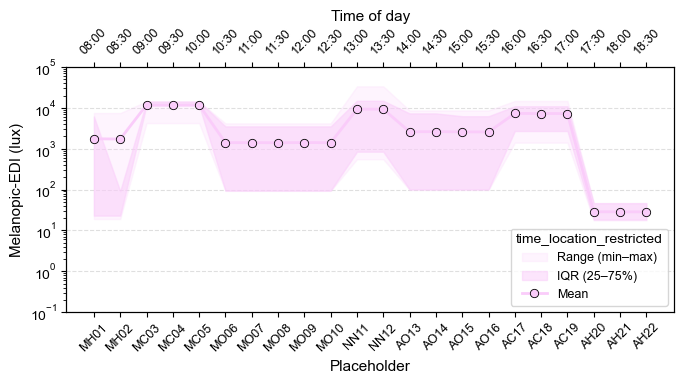

In [148]:
plot_model_timeline_iqr_multi(
    sequence_dict=sequence_dict,
    placeholders=placeholders,
    times=times,
    metric_name="Melanopic-EDI (lux)",
    save_dir="../results/plots",
    dpi=300,
)

## Model comparison

In [ ]:
# specify files in the order you want
file_order = [
"Timeline_naive_melanopic.pdf",
    "Timeline_naive_indoor_melanopic.pdf",
    "Timeline_naive_outdoor_melanopic.pdf",
    "Timeline_time_restricted_melanopic.pdf",
    "Timeline_location_restricted_melanopic.pdf",
    "Timeline_time_location_restricted_melanopic.pdf"
]    

In [66]:
# model priority order
model_order = [
    "naive",
    "naive_indoor",
    "naive_outdoor",
    "time_restricted",
    "location_restricted",
    "time_location_restricted"
]

priority = {name: i for i, name in enumerate(model_order)}

In [ ]:
folder = "../results/plots/LightLogR/"
pattern = re.compile(r"Timeline.*\.pdf$")

files = [os.path.join(folder, f) for f in file_order]

# convert PDFs to images
images = [convert_from_path(f, dpi=200)[0] for f in files]

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img in zip(axes.flat, images):
    ax.imshow(img)
    ax.axis('off')  # remove axes

plt.tight_layout()

In [ ]:
folder = "../results/tables/LightLogR/timeline/"
pattern = re.compile(r"(.*)_melanopic\.csv$")
files = [os.path.join(folder, f) for f in os.listdir(folder) if pattern.match(f)]

records = []

for f in sorted(files):
    df = pd.read_csv(f)

    mean_val = df["mean"].mean()
    min_val  = df["min"].mean()
    max_val  = df["max"].mean()

    tag = pattern.match(os.path.basename(f)).group(1) + " model"

    records.append({
        "label": tag,
        "mean": mean_val,
        "min": min_val,
        "max": max_val
    })

plot_df = pd.DataFrame(records)

# create figure
fig, ax = plt.subplots(figsize=(9, len(plot_df) * 0.45))

y_positions = range(len(plot_df))

colors = cmap(np.linspace(0, 1, len(plot_df)))

for i, (idx, row) in enumerate(plot_df.iterrows()):
    c = colors[i]
    # draw min-max line
    ax.plot([row["min"], row["max"]], [i, i], color=c, linewidth=2)
    # draw mean point
    ax.plot(row["mean"], i, 'o', color=c, markersize=6)

ax.set_yticks(list(y_positions))
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Melanopic-EDI")
ax.set_xscale("log")
ax.set_title("Mean and Min–Max (log scale)")
ax.grid(axis='x', linestyle='--', alpha=0.3)

# legend
mean_dot = plt.Line2D([0], [0], marker='o', color='black', linestyle='None', label='Mean')
range_line = plt.Line2D([0], [0], color='black', linewidth=2, label='Min–Max')
ax.legend(handles=[mean_dot, range_line], loc='upper left', frameon=False)

plt.tight_layout()

In [ ]:
folder = "../results"

# exact order of files (the unique part of filename before .csv)
model_order = [ 
    "naive_melanopic_sequence",
    "naive_indoor_melanopic_sequence",
    "naive_outdoor_melanopic_sequence",
    "time_restricted_melanopic_sequence",
    "location_restricted_melanopic_sequence",
    "time_location_restricted_melanopic_sequence"
]

all_model_means = []
model_labels = []

for model_name in model_order:
    # construct the full filename (assuming *.csv)
    fname = [f for f in os.listdir(folder) if model_name in f.lower()]
    if len(fname) == 0:
        continue  # skip missing files
    fname = fname[0]  # take the first match
    label = fname.lower().replace(".csv", "")  # label for plot
    model_labels.append(label)

    # read CSV memory-safe
    df = pd.read_csv(os.path.join(folder, fname))
    df_numeric = df.iloc[:, 1:]  # drop first column (non-numeric index)
    col_means = df_numeric.mean(axis=0).values
    all_model_means.append(col_means)

    del df, df_numeric
    gc.collect()

# ----------------- PLOT -----------------
fig, ax = plt.subplots(figsize=(12, 6))
n = len(all_model_means)

# put grid behind
ax.set_axisbelow(True)

# categorical colors
colors = [cmap(i / (n - 1)) for i in range(n)] if n > 1 else [cmap(0.5)]

# violins
parts = ax.violinplot(all_model_means, showmeans=False, showextrema=False, vert=False)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)  # put violins above grid
# mean and median lines
for i, col in enumerate(all_model_means):
    pos = i + 1
    mean_val = np.mean(col)
    median_val = np.median(col)
    ax.plot( [mean_val, mean_val], [pos - 0.2, pos + 0.2], color='black', linewidth=2, label='Mean' if i==0 else "", zorder=3)
    ax.plot( [median_val, median_val], [pos - 0.2, pos + 0.2], color='red', linewidth=2, linestyle='--', label='Median' if i==0 else "", zorder=3)

# x-axis labels: remove '_melanopic_sequence'

ax.set_xscale("log")
ax.set_xlim(1e1, 1e5)
ax.set_xlabel("Melanopic-EDI (mean per synthetic sequence)")


# y-axis log scale and grid `if i want to ordered y axis top to bottom: (ax.invert_yaxis()),`
y_labels = [label.replace("_melanopic_sequence", "") for label in model_labels]
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(y_labels, ha="right")

#ax.set_title("Model Comparison — Synthetic Sequence Mean Distributions")
ax.grid(which="both", linestyle="--", linewidth=0.6, alpha=0.7, zorder=1)

# legend
mean_line = Line2D([0], [0], color='black', linewidth=2, label='Mean')
median_line = Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Median')
ax.legend(handles=[mean_line, median_line], loc='upper right', frameon=False)

plt.tight_layout()

## Real world light exposure dataset


In [ ]:
# read CSV
real_world_df = pd.read_csv(r'..\data\real_world_dataset.csv')
# Add time if missing
real_world_df["Datetime"] = real_world_df["Datetime"].apply(
    lambda x: x if ":" in x else f"{x} 00:00"
)
real_world_df["Datetime"] = pd.to_datetime(real_world_df["Datetime"], format="%d.%m.%Y %H:%M")
real_world_df.head()

In [ ]:
df_day = real_world_df[
    (real_world_df["Datetime"].dt.time >= pd.to_datetime("08:00").time()) &
    (real_world_df["Datetime"].dt.time <= pd.to_datetime("18:30").time())
]
df_day = df_day[df_day["MEDI"] >= 0.9]


In [ ]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())

all_site_values = []
site_labels = []

for site in sites:
    vals = df_day.loc[df_day["Site"] == site, "MEDI"].dropna().values
    if len(vals) == 0:
        continue
    all_site_values.append(vals)
    site_labels.append(site)

In [ ]:
# Group by site and get min/max with corresponding times
site_summary = []

for site in df_day["Site"].unique():
    df_site = df_day[df_day["Site"] == site]
    if df_site.empty:
        continue

    total_count = len(df_site)
    
    # min MEDI and its datetime
    min_idx = df_site["MEDI"].idxmin()
    min_val = df_site.loc[min_idx, "MEDI"]
    min_time = df_site.loc[min_idx, "Datetime"]

    # max MEDI and its datetime
    max_idx = df_site["MEDI"].idxmax()
    max_val = df_site.loc[max_idx, "MEDI"]
    max_time = df_site.loc[max_idx, "Datetime"]

    # percentage of MEDI < 1
    pct_below_1 = (df_site["MEDI"] < 1).sum() / total_count * 100

    # percentage of MEDI < 10
    pct_below_10 = (df_site["MEDI"] < 10).sum() / total_count * 100

    site_summary.append({
        "Site": site,
        "Min_MEDI": min_val,
        "Min_time": min_time,
        "Max_MEDI": max_val,
        "Max_time": max_time,
        "%_below_1": pct_below_1,
        "%_below_10": pct_below_10
    })

# Convert to DataFrame
site_summary_df = pd.DataFrame(site_summary)
site_summary_df

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
n = len(all_site_values)

ax.set_axisbelow(True)

# --- compute in log space to avoid KDE boundary cut ---
log_all_site_values = [np.log10(vals) for vals in all_site_values]

# Horizontal violins (in log10 space)
parts = ax.violinplot(
    log_all_site_values,
    showmeans=False,
    showextrema=False,
    vert=False
)

# color and style
for body in parts["bodies"]:
    body.set_facecolor("tab:blue")
    body.set_edgecolor("black")
    body.set_alpha(0.85)
    body.set_zorder(2)

# Mean and median lines (also in log10 space)
for i, vals in enumerate(all_site_values):
    pos = i + 1
    mean_val = np.log10(np.mean(vals))
    median_val = np.log10(np.median(vals))

    ax.plot([mean_val, mean_val], [pos - 0.2, pos + 0.2],
            color="black", linewidth=2, label="Mean" if i == 0 else "", zorder=3)

    ax.plot([median_val, median_val], [pos - 0.2, pos + 0.2],
            color="red", linewidth=2, linestyle="--", label="Median" if i == 0 else "", zorder=3)

# Y-axis labels
ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(site_labels)

# Limits: 1e1 to 1e5 (in log10 space: 1 to 5)
xmin, xmax = np.log10(1e1), np.log10(1e5)
ax.set_xlim(xmin, xmax)

# Major ticks at integer log10 positions
ax.xaxis.set_major_locator(MultipleLocator(1))

# Minor ticks at log10(2..9) within each decade (true log-style minors)
subs = np.log10(np.arange(2, 10))  # log10(2..9)
decades = np.arange(np.floor(xmin), np.ceil(xmax))  # 1..4 for 10^1..10^5 span
minor_ticks = (decades[:, None] + subs[None, :]).ravel()
minor_ticks = minor_ticks[(minor_ticks >= xmin) & (minor_ticks <= xmax)]
ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))

# Major labels as 10^k
def pow10_tex_formatter(x, pos):
    k = int(np.round(x))
    if np.isclose(x, k, atol=1e-8):
        return rf"$10^{{{k}}}$"
    return ""

ax.xaxis.set_major_formatter(FuncFormatter(pow10_tex_formatter))

ax.set_xlabel("Melanopic-EDI")
# ax.set_title("Daytime MEDI Distributions by Site")

# Grid: major + minor (minor now truly logarithmic)
ax.grid(which="major", linestyle="--", linewidth=0.6, alpha=0.7, zorder=1)
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.5, zorder=1)

# Legend
mean_line = Line2D([0], [0], color="black", linewidth=2, label="Mean")
median_line = Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Median")
ax.legend(handles=[mean_line, median_line], loc="upper right", frameon=False)

In [ ]:
# get sorted list of sites
sites = sorted(df_day["Site"].unique())
n_sites = len(sites)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()

# formatter: convert log10(MEDI) -> MEDI label
def log_to_medi_formatter(x, pos):
    return f"{10**x:.0f}"

for i, site in enumerate(sites):
    vals = df_day[df_day["Site"] == site]["MEDI"].values
    vals = vals[vals > 0]

    log_vals = np.log10(vals)

    axes[i].hist(
        log_vals,
        bins=30,
        color="tab:blue",
        edgecolor="black",
        alpha=0.7
    )

    axes[i].xaxis.set_major_formatter(FuncFormatter(log_to_medi_formatter))

    axes[i].set_title(site)
    axes[i].set_xlabel("MEDI")
    axes[i].set_ylabel("Count")

# remove empty subplots
for j in range(n_sites, 8):
    fig.delaxes(axes[j])

plt.suptitle(
    "MEDI Distributions per Site\n(linear bins in log space)",
    fontsize=16
)